# Day 2 — PyTorch: Building Neural Networks

## Note 2.3 — Building and Training an MLP You Can Defend

### Learning goal and outcome

**Goal.** Build a multilayer perceptron (MLP) on real, imbalanced tabular data, train it with a loop you wrote yourself, and be able to defend every important choice in that loop — including the choice of whether the network was worth building at all.

An **MLP (multilayer perceptron)** is a feed-forward neural network made from fully connected (`Linear`) layers and usually nonlinear activation functions such as ReLU. “Feed-forward” means information moves from the input toward the output; the network does not contain a recurrent memory of previous examples.

This note is deliberately about **mechanics and reasoning**. You are not expected to memorise PyTorch APIs without understanding what they are doing. Whenever a technical term first appears, the note explains the idea first and then gives the term you will see in the code.

**Outcome.** By the end of this note you will have a trained model, a checkpoint you could resume from, learning curves you can read, and an honest comparison against two baselines. You will also modify the training loop rather than only run it. That ability to change and defend the loop is Day 2’s end-of-day competency.


### Objectives

By the end of this note you will be able to:

- inspect a model with `parameters()` and `named_parameters()`, and count its trainable parameters by hand;
- explain **parameter registration**: how PyTorch keeps track of the weights, biases, and child layers that belong to a model;
- compose layers with `nn.Sequential`, reusable sub-modules, `ModuleList`, and nested module trees;
- trace shapes through a network with a dry run and forward hooks before real data touches it;
- choose between a one-logit and a two-logit output head and explain the corresponding label and loss conventions;
- explain what a **logit** is and why `BCEWithLogitsLoss` is preferable to manually applying `sigmoid` and then `BCELoss` during training;
- write a training loop with correct gradient handling, loss accumulation, and `.item()` discipline;
- explain exactly what `loss.backward()` calculates and why gradients are needed by the optimizer;
- write a validation pass protected by `model.eval()` and `torch.no_grad()`, and explain why those two operations solve different problems;
- read learning curves and identify mild overfitting without reaching for a fix before diagnosing the problem;
- evaluate an imbalanced classifier against a majority-class baseline and a logistic regression baseline;
- distinguish **ranking quality** from **classification at a chosen threshold**, and connect ranking to a limited call-centre capacity;
- save and resume a checkpoint containing model weights, optimizer state, epoch, and configuration;
- modify the loop yourself: class weighting, a new per-epoch metric, gradient inspection, and early stopping.


### Dataset used

**UCI Bank Marketing**, encoded in Note 2.2 — 45,211 rows split 70/15/15 into 31,647 training, 6,782 validation and 6,782 test examples. After one-hot encoding there are 50 input features, and the positive class makes up about 11.7% of each split.

A **positive example** is a customer whose target is `yes` — the outcome we are trying to identify. An **imbalanced classification problem** is one where one class is much less common than the other. Here, roughly 88.3% are negative and only 11.7% are positive. That imbalance is why plain accuracy can be misleading and why we will pay attention to ROC-AUC and average precision.

This note loads `data/bank_processed.npz` if Note 2.2 produced it, and rebuilds it from the raw CSV if not. Either way it is intended to run standalone on a fresh Colab session.

The `duration` column was dropped in Note 2.2 as a **target leak**. A target leak is information in the input that would not legitimately be available at prediction time but is strongly related to the target. Keeping such a column can make a model appear much better than it really is. It stays dropped here.


### Table of contents

1. [nn.Module past the introduction](#s1)
2. [Composing blocks](#s2)
3. [Tracing shapes through a model](#s3)
4. [Choosing the output layer and the loss honestly](#s4)
5. [The training loop, expanded](#s5)
6. [The validation loop and what it must never do](#s6)
7. [Running it, and the honest verdict](#s7)
8. [Checkpointing that survives a crash](#s8)
9. [Now modify the loop yourself](#s9)
10. [Conclusion](#s10)

### Runtime budget

| Section | Approximate time |
|---|---|
| Setup and data loading | 10–60 s (60 only if re-downloading) |
| Sections 1–4 — model construction and inspection | under 10 s |
| Section 7 — the 30-epoch training run | ~20 s on CPU |
| Section 9 — three modified runs | ~30 s combined |
| Everything else | under 10 s |

Total execution is roughly **two minutes on CPU**. The models here are small on purpose: a 50→64→32→1 network has about 5,400 trainable parameters.

A **parameter** is a numerical value inside the model that training is allowed to change, usually a weight or bias. “5,400 parameters” therefore means the optimizer has roughly 5,400 trainable numbers available to adjust.

The point of Day 2 is not to train a large model. It is to understand the machinery well enough that, when a larger model fails, you know what the machinery is supposed to be doing.


### Environment setup

In [1]:
# Pinned for reproducibility. Uncomment to install in a fresh environment (Colab / Kaggle).
# !pip install -q torch==2.14.0 numpy==2.4.4 pandas==3.0.2 scikit-learn==1.8.0 matplotlib==3.10.8

import os
import sys
import time
import copy
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader

import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, confusion_matrix, f1_score,
)

print(f"python       : {sys.version.split()[0]}")
print(f"torch        : {torch.__version__}")
print(f"numpy        : {np.__version__}")
print(f"pandas       : {pd.__version__}")
print(f"scikit-learn : {sklearn.__version__}")

python       : 3.13.9
torch        : 2.14.0
numpy        : 2.3.5
pandas       : 2.3.3
scikit-learn : 1.7.2


In [2]:
def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    return torch.device("cpu")


def seed_everything(seed: int = 42) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


SEED = 42
DEVICE = get_device()
seed_everything(SEED)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
CKPT_DIR = Path("checkpoints")
CKPT_DIR.mkdir(exist_ok=True)

print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"  {torch.cuda.get_device_name(0)}")
print(f"Seed  : {SEED}")

Device: mps
Seed  : 42


### Loading the data

If Note 2.2 ran in this working directory, `bank_processed.npz` is already there. If not — for example, in a fresh Colab session or after clearing the runtime — the fallback rebuilds it from the raw CSV using the same split, encoding, scaling, and random seed.

The important idea here is **reproducibility**. A fixed seed and a fixed preprocessing procedure let us recreate the same train/validation/test construction rather than silently changing the experiment each time the notebook is opened.

The three splits have different jobs:

- **training set:** used to calculate gradients and change model parameters;
- **validation set:** used while developing the model to compare choices and monitor generalisation;
- **test set:** held back for the final assessment. We do not use it to choose the model or training epoch in this note.


In [3]:
PROCESSED = DATA_DIR / "bank_processed.npz"
BANK_CSV = DATA_DIR / "bank-full.csv"
BANK_URL = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"


def rebuild_from_raw() -> dict:
    """Reproduce Note 2.2's pipeline exactly. Used only if the .npz is missing."""
    if not BANK_CSV.exists():
        print("Downloading UCI Bank Marketing ...")
        outer = DATA_DIR / "bank+marketing.zip"
        urllib.request.urlretrieve(BANK_URL, outer)
        with zipfile.ZipFile(outer) as z:
            z.extract("bank.zip", DATA_DIR)
        with zipfile.ZipFile(DATA_DIR / "bank.zip") as z:
            z.extract("bank-full.csv", DATA_DIR)
        outer.unlink()
        (DATA_DIR / "bank.zip").unlink()

    df = pd.read_csv(BANK_CSV, sep=";").drop(columns=["duration"])   # target leak
    y_all = (df.pop("y") == "yes").astype(np.int64).values
    numeric = [c for c in df.columns if df[c].dtype.kind in "iuf"]
    categorical = [c for c in df.columns if c not in numeric]

    X_tr, X_tmp, y_tr, y_tmp = train_test_split(
        df, y_all, test_size=0.30, stratify=y_all, random_state=SEED)
    X_va, X_te, y_va, y_te = train_test_split(
        X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)

    train_ohe = pd.get_dummies(X_tr, columns=categorical)
    names = list(train_ohe.columns)
    scaler = StandardScaler().fit(train_ohe[numeric])

    def finish(frame):
        out = pd.get_dummies(frame, columns=categorical).reindex(
            columns=names, fill_value=0).astype(np.float32)
        out[numeric] = scaler.transform(out[numeric]).astype(np.float32)
        return out.values.astype(np.float32)

    return dict(
        X_train=finish(X_tr), y_train=y_tr,
        X_val=finish(X_va), y_val=y_va,
        X_test=finish(X_te), y_test=y_te,
        feature_names=np.array(names, dtype=object),
    )


if PROCESSED.exists():
    print(f"Loading {PROCESSED} (produced by Note 2.2)")
    blob = dict(np.load(PROCESSED, allow_pickle=True))
else:
    print(f"{PROCESSED} not found — rebuilding from the raw CSV")
    blob = rebuild_from_raw()
    np.savez_compressed(PROCESSED, **blob)

X_train, y_train = blob["X_train"], blob["y_train"]
X_val, y_val = blob["X_val"], blob["y_val"]
X_test, y_test = blob["X_test"], blob["y_test"]
feature_names = list(blob["feature_names"])

N_FEATURES = X_train.shape[1]

for name, X_, y_ in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(f"  {name:<6} {X_.shape[0]:>6,} x {X_.shape[1]}  positive rate {y_.mean():.4f}")

Loading data/bank_processed.npz (produced by Note 2.2)
  train  31,647 x 50  positive rate 0.1170
  val     6,782 x 50  positive rate 0.1171
  test    6,782 x 50  positive rate 0.1169


In [4]:
X_val

array([[ 0.85833985, -0.59722406,  0.38330433, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.199308  , -0.46465886,  0.26326996, ...,  1.        ,
         0.        ,  0.        ],
       [-0.36557648,  0.28382978,  0.50333863, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.76419246, -0.3438193 , -1.4172109 , ...,  0.        ,
         0.        ,  1.        ],
       [-1.2129033 , -0.59722406, -1.0571078 , ...,  0.        ,
         0.        ,  1.        ],
       [ 1.4232243 ,  1.4348999 ,  0.50333863, ...,  0.        ,
         0.        ,  1.        ]], shape=(6782, 50), dtype=float32)

In [5]:
BATCH_SIZE = 256

In [6]:
def to_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(
        torch.from_numpy(X),
        torch.from_numpy(y).float().unsqueeze(1),      # (N, 1) to match a 1-logit head
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

In [7]:
seed_everything(SEED)

In [8]:
train_loader = to_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader = to_loader(X_val, y_val, 1024, shuffle=False)
test_loader = to_loader(X_test, y_test, 1024, shuffle=False)

In [9]:
xb, yb = next(iter(train_loader))
assert xb.shape == (BATCH_SIZE, N_FEATURES) and xb.dtype == torch.float32
assert yb.shape == (BATCH_SIZE, 1) and yb.dtype == torch.float32
print(f"train {len(train_loader)} batches | val {len(val_loader)} | test {len(test_loader)}")
print(f"one batch: x {tuple(xb.shape)} {xb.dtype}, y {tuple(yb.shape)} {yb.dtype}  — contract holds")

train 124 batches | val 7 | test 7
one batch: x (256, 50) torch.float32, y (256, 1) torch.float32  — contract holds


## 1. `nn.Module` past the introduction

You have already subclassed `nn.Module`, defined `forward`, and seen that the code works. The important question now is: **what does `nn.Module` actually keep track of for us?**

Start with the concrete idea. A neural network contains numerical values that training is allowed to change. Those values are the model’s **parameters** — for example, the weights and bias of a `Linear` layer.

PyTorch needs to know which objects inside your Python object are part of the neural network. When you assign a layer such as `nn.Linear(...)` to an attribute of an `nn.Module` inside `__init__`, PyTorch records that layer as a child module. The parameters inside that layer are then part of the model’s registered parameters.

This tracking is called **parameter/module registration**. It is not cosmetic bookkeeping. Later, several PyTorch operations rely on this record:

- `model.parameters()` finds the trainable tensors that an optimizer should update;
- `model.to(device)` moves registered parameters and buffers to CPU, CUDA, or another device;
- `state_dict()` collects the registered model state so it can be saved;
- `model.train()` and `model.eval()` propagate the appropriate mode to child modules.

So when this note says that a layer is “registered”, read that as: **PyTorch knows that this object belongs to the model and can include it in these model-management operations.**

In [10]:
class TinyNet(nn.Module):
    def __init__(self, in_features: int, hidden: int = 8):
        super().__init__()                                # ALWAYS first: sets up the registry
        self.fc1 = nn.Linear(in_features, hidden)
        self.fc2 = nn.Linear(hidden, 1)
        self.activation = nn.ReLU()
        self.dropout_rate = 0.0                           # a plain float — NOT registered

    def forward(self, x):
        return self.fc2(self.activation(self.fc1(x)))

In [11]:
tiny = TinyNet(in_features=6, hidden=8)
print(tiny)
print()
print("Registered parameters:")
for name, p in tiny.named_parameters():
    print(f"  {name:<12} {str(tuple(p.shape)):<12} requires_grad={p.requires_grad}")

print(f"\nself.dropout_rate = {tiny.dropout_rate} is a plain attribute.")
print("It does not appear above, because it is not a Parameter or a Module.")

TinyNet(
  (fc1): Linear(in_features=6, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=1, bias=True)
  (activation): ReLU()
)

Registered parameters:
  fc1.weight   (8, 6)       requires_grad=True
  fc1.bias     (8,)         requires_grad=True
  fc2.weight   (1, 8)       requires_grad=True
  fc2.bias     (1,)         requires_grad=True

self.dropout_rate = 0.0 is a plain attribute.
It does not appear above, because it is not a Parameter or a Module.


### The registry is what makes the optimizer possible

An **optimizer** is the object that changes model parameters after gradients have been calculated. Adam is one example.

When you write:

```python
torch.optim.Adam(model.parameters(), ...)
```

`model.parameters()` gives Adam the tensors it is allowed to update. This is why registration matters: if a layer’s parameters are not registered, the optimizer never receives them.

The dangerous part is that this usually does **not** produce an error. The model can still run a forward pass, calculate a loss, and run `backward()`. It simply leaves some weights unchanged. That is a silent training bug: the program runs, but the model is only partly learning.


In [12]:
class BrokenNet(nn.Module):
    """A common mistake: layers stored in a plain Python list are invisible."""
    def __init__(self, in_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 8)
        self.hidden_layers = [nn.Linear(8, 8), nn.Linear(8, 8)]     # a plain list!
        self.out = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        for layer in self.hidden_layers:
            x = torch.relu(layer(x))
        return self.out(x)

In [13]:
class FixedNet(nn.Module):
    """nn.ModuleList registers everything it holds."""
    def __init__(self, in_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 8)
        self.hidden_layers = nn.ModuleList([nn.Linear(8, 8), nn.Linear(8, 8)])
        self.out = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        for layer in self.hidden_layers:
            x = torch.relu(layer(x))
        return self.out(x)

In [14]:
def count_params(model):
    return sum(p.numel() for p in model.parameters())


broken, fixed = BrokenNet(6), FixedNet(6)
print(f"BrokenNet: {count_params(broken):>4} parameters visible to an optimizer")
print(f"FixedNet : {count_params(fixed):>4} parameters visible to an optimizer")
print(f"\nBoth run forward identically. Both produce a loss. Both call backward().")
print(f"BrokenNet silently never updates {count_params(fixed) - count_params(broken)} of its weights.")

x_demo = torch.randn(4, 6)
print(f"\nforward works on both: broken {tuple(broken(x_demo).shape)}, "
      f"fixed {tuple(fixed(x_demo).shape)}")

BrokenNet:   65 parameters visible to an optimizer
FixedNet :  209 parameters visible to an optimizer

Both run forward identically. Both produce a loss. Both call backward().
BrokenNet silently never updates 144 of its weights.

forward works on both: broken (4, 1), fixed (4, 1)


That is the same category of bug as Note 2.1’s silent broadcast: the program runs, produces plausible numbers, and does not necessarily tell you that something is wrong. The defence is the same — **check the structure instead of assuming it**:

```python
assert count_params(model) == expected, "parameter count mismatch"
```

If you need a collection of layers, use a PyTorch container that knows it is holding modules:

- `nn.ModuleList` is a list-like container for child modules;
- `nn.ModuleDict` is a dictionary-like container for named child modules.

A plain Python list or dictionary does not automatically register the modules it contains.

### Why you call the module, not `forward`

There is another layer of machinery around `forward`. When you write:

```python
model(x)
```

Python invokes the module’s `__call__` machinery, which in turn handles the forward pass and PyTorch features such as hooks. Calling `model.forward(x)` directly jumps past that machinery.

So the normal rule is simple: **call the model as `model(x)`, not `model.forward(x)`**. You define `forward`; PyTorch’s module interface decides how that forward computation is wrapped.

In [15]:
x_demo = torch.randn(4, 6)

direct = tiny(x_demo)              # correct
bypass = tiny.forward(x_demo)      # runs, gives the same numbers, skips machinery

print(f"tiny(x)         -> {tuple(direct.shape)}")
print(f"tiny.forward(x) -> {tuple(bypass.shape)}")
print(f"identical values: {torch.equal(direct, bypass)}")
print()
print("Calling the module invokes __call__, which runs registered hooks around forward().")
print("Calling .forward() directly skips them. Section 3 uses hooks, so this matters.")

tiny(x)         -> (4, 1)
tiny.forward(x) -> (4, 1)
identical values: True

Calling the module invokes __call__, which runs registered hooks around forward().
Calling .forward() directly skips them. Section 3 uses hooks, so this matters.


**Questions to sit with:**

1. `BrokenNet` and `FixedNet` differ by 144 parameters. If you trained `BrokenNet`, would the loss
   go down at all? Predict, then reason about which layers *are* in the registry.
2. `super().__init__()` must come first. What specifically fails if you assign `self.fc1` before
   calling it?

## 2. Composing blocks

A network is easier to reason about when you can describe it as a sequence of reusable pieces rather than as one long expression.

There are three common ways to assemble a network, and they trade brevity against control:

1. **`nn.Sequential`** — useful when the data simply flows through a fixed sequence of layers;
2. **a reusable sub-module** — useful when a pattern such as `Linear → ReLU` appears more than once;
3. **a custom `nn.Module` with named child modules** — useful when the forward pass contains branching, skip/residual connections, multiple inputs, or other logic that a straight sequence cannot express.

The important idea is **composition**: a large model can be built from smaller modules, and those modules can themselves contain modules.

In [16]:
# --- Style A: nn.Sequential. Concise. No control flow in forward. ---
seq_model = nn.Sequential(
    nn.Linear(N_FEATURES, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 1),
)

seq_model

Sequential(
  (0): Linear(in_features=50, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)

In [17]:
# --- Style B: an explicit subclass. Verbose. Full control. ---
class ExplicitMLP(nn.Module):
    def __init__(self, in_features, h1=64, h2=32):
        super().__init__()
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.out = nn.Linear(h2, 1)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.fc1(x))
        x = self.act(self.fc2(x))
        return self.out(x)

In [18]:
explicit = ExplicitMLP(N_FEATURES)

print(f"Sequential : {count_params(seq_model):,} parameters")
print(f"Explicit   : {count_params(explicit):,} parameters")
print("Same architecture, same count. The difference is what you can express in forward().")

Sequential : 5,377 parameters
Explicit   : 5,377 parameters
Same architecture, same count. The difference is what you can express in forward().


### A reusable block, and why blocks matter

Real neural-network architectures often repeat the same small pattern. For this model the repeated pattern is essentially:

```text
Linear → ReLU
```

Instead of writing that pattern repeatedly, we can package it into a small module called a **block**. A block is simply a reusable piece of a larger network.

The technical idea is **composition**: we construct a larger model by putting smaller modules together. This makes the model easier to read, inspect, change, and reuse. The same design idea appears in much larger architectures, including the repeated blocks used in Transformers.

In [19]:
class DenseBlock(nn.Module):
    """Linear -> activation. One motif, defined once."""
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        self.act = nn.ReLU()

    def forward(self, x):
        return self.act(self.linear(x))

In [20]:
class BankMLP(nn.Module):
    """The model this note trains. Width list makes depth a configuration choice."""

    def __init__(self, in_features: int, hidden_sizes=(64, 32), out_features: int = 1):
        super().__init__()
        sizes = [in_features, *hidden_sizes]
        self.blocks = nn.ModuleList(
            DenseBlock(sizes[i], sizes[i + 1]) for i in range(len(hidden_sizes))
        )
        self.head = nn.Linear(sizes[-1], out_features)

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        return self.head(x)          # raw logits — no sigmoid, see Section 4

In [21]:
N_FEATURES

50

In [22]:
seed_everything(SEED)
model = BankMLP(N_FEATURES, hidden_sizes=(64, 32))
print(model)

BankMLP(
  (blocks): ModuleList(
    (0): DenseBlock(
      (linear): Linear(in_features=50, out_features=64, bias=True)
      (act): ReLU()
    )
    (1): DenseBlock(
      (linear): Linear(in_features=64, out_features=32, bias=True)
      (act): ReLU()
    )
  )
  (head): Linear(in_features=32, out_features=1, bias=True)
)


In [23]:
print("The module tree, and where the parameters live:\n")
total = 0
for name, p in model.named_parameters():
    total += p.numel()
    print(f"  {name:<24} {str(tuple(p.shape)):<12} {p.numel():>6,}")
print(f"  {'TOTAL':<24} {'':<12} {total:>6,}")

by_hand = (N_FEATURES * 64 + 64) + (64 * 32 + 32) + (32 * 1 + 1)
print(f"\nBy hand: ({N_FEATURES}x64 + 64) + (64x32 + 32) + (32x1 + 1) = {by_hand:,}")
print(f"Matches: {by_hand == total}")

print(f"\nMemory for the weights alone, float32: {total * 4 / 1024:.1f} KB")
print("Adam also stores two running averages per parameter, so training")
print(f"state is roughly 3x that: {total * 4 * 3 / 1024:.1f} KB. Day 4 budgets this properly.")

The module tree, and where the parameters live:

  blocks.0.linear.weight   (64, 50)      3,200
  blocks.0.linear.bias     (64,)            64
  blocks.1.linear.weight   (32, 64)      2,048
  blocks.1.linear.bias     (32,)            32
  head.weight              (1, 32)          32
  head.bias                (1,)              1
  TOTAL                                  5,377

By hand: (50x64 + 64) + (64x32 + 32) + (32x1 + 1) = 5,377
Matches: True

Memory for the weights alone, float32: 21.0 KB
Adam also stores two running averages per parameter, so training
state is roughly 3x that: 63.0 KB. Day 4 budgets this properly.


The dotted parameter names are not arbitrary labels. They describe the path through the **module tree**.

A module tree is simply the nested structure of the model. For example:

```text
BankMLP
├── blocks
│   ├── 0
│   │   ├── linear
│   │   └── act
│   └── 1
│       ├── linear
│       └── act
└── head
```

So `blocks.0.linear.weight` means:

> `BankMLP` → `blocks` → block `0` → `linear` layer → its `weight` tensor.

Those paths become keys in `state_dict()`, which is PyTorch’s dictionary-like representation of the model state. This is why renaming a submodule can affect whether an old checkpoint loads cleanly: the saved keys may no longer match the new module-tree paths.

This is also why Section 8 saves the architecture configuration alongside the weights. The weights are meaningful only when we reconstruct the architecture they belong to.


> **🖼 IMAGE 2.3.1 — module tree versus tensor flow**

<div align="center">

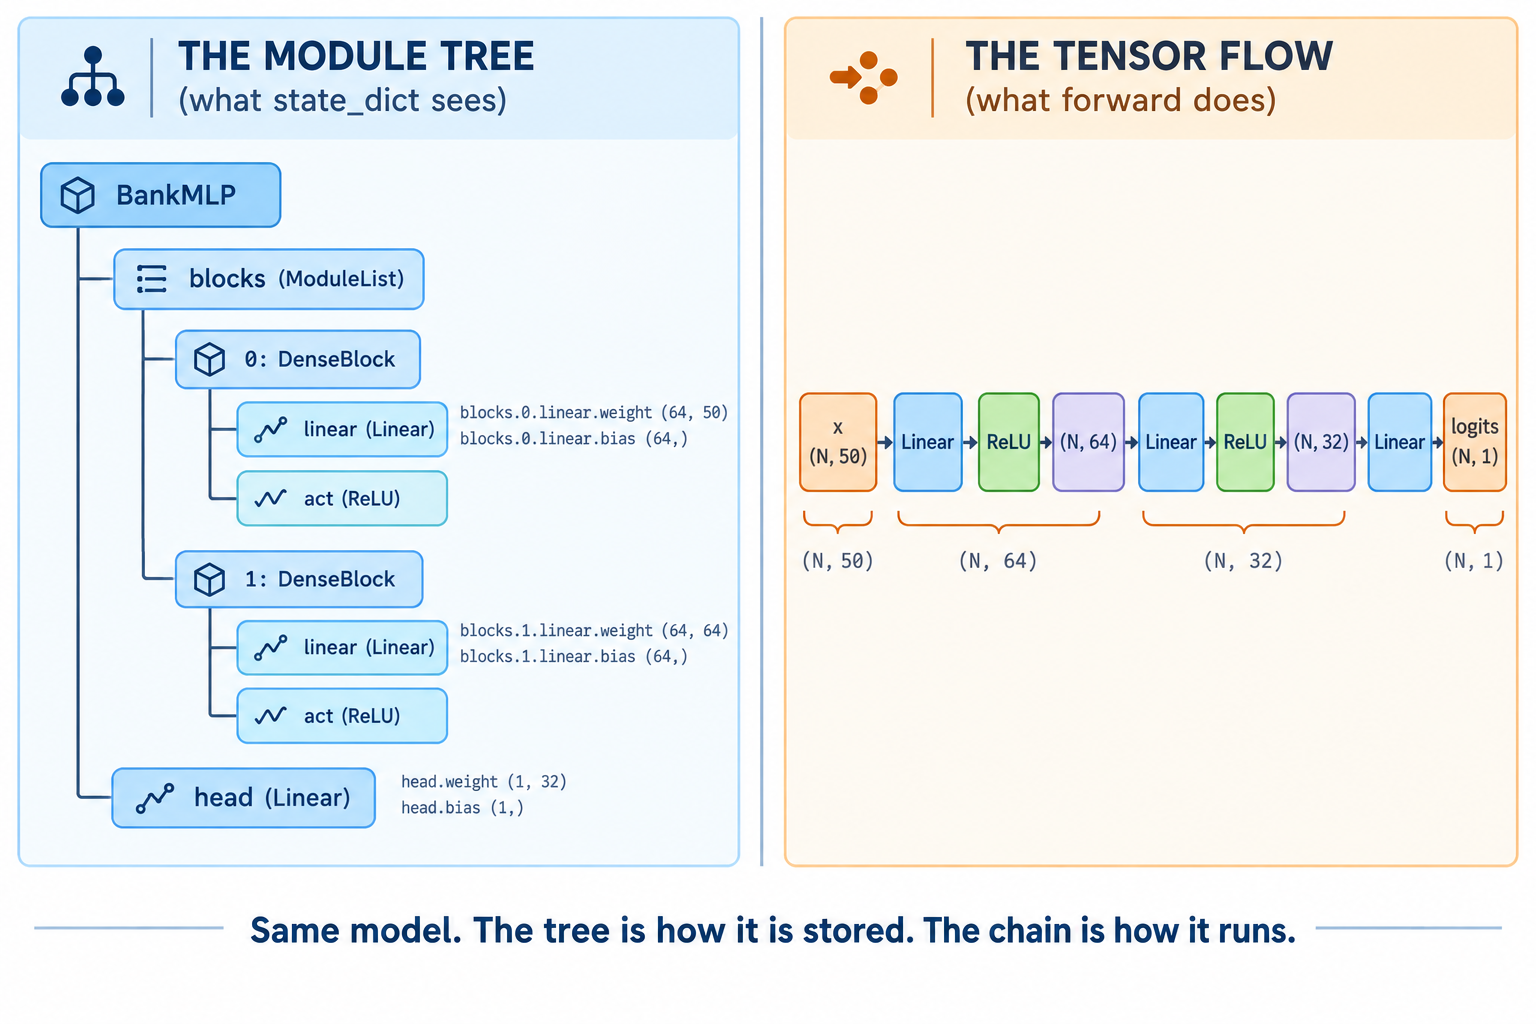


</div>

**Questions to sit with:**

1. `BankMLP(N_FEATURES, hidden_sizes=(64, 32))` has about 5,400 parameters. What does `hidden_sizes=(256, 128, 64)` give you? Compute it before running it. Remember that each `Linear` layer has a weight matrix and, when enabled, a bias vector.
2. `nn.Sequential` cannot express a residual connection such as `x + f(x)` using only a simple chain. Why does that require access to the original `x`, and what does that tell you about when to reach for a custom `nn.Module`?


## 3. Tracing shapes through a model

Note 2.1’s shape clinic dealt with one layer at a time. In a real model, a shape mistake may originate several layers before the line that finally fails. The error message usually identifies the operation that could not proceed, not necessarily the earlier configuration choice that caused the mismatch.

The first tool is deliberately simple: **dry-run a fake batch before you touch real data.**

A **dry run** means sending artificial data through the model only to test the wiring. We do not care about the predictions. We care that the input shape is accepted and that the output shape is what the next stage expects.

In [24]:
def dry_run(model: nn.Module, in_features: int, batch_size: int = 2) -> torch.Tensor:
    """Push a fake batch through and report. Catches shape bugs in milliseconds."""
    model.eval()
    fake = torch.randn(batch_size, in_features)
    with torch.no_grad():
        out = model(fake)
    print(f"dry run: in {tuple(fake.shape)} -> out {tuple(out.shape)}")
    return out


_ = dry_run(model, N_FEATURES)

# The same dry run against a WRONG feature count fails instantly and informatively.
try:
    dry_run(model, N_FEATURES + 7)
except RuntimeError as e:
    print(f"\nWrong input width caught immediately: {str(e)[:100]}")

dry run: in (2, 50) -> out (2, 1)

Wrong input width caught immediately: mat1 and mat2 shapes cannot be multiplied (2x57 and 50x64)


### Forward hooks: seeing every intermediate shape

A **hook** is a function that PyTorch can call automatically when a particular event happens inside a module. A **forward hook** runs when a module has performed its forward computation, so it lets us inspect what went into a layer and what came out without rewriting the model.

Think of a forward hook as temporarily attaching a measuring instrument to a layer.

Register one on each leaf submodule and run one fake batch. You then get a trace of the tensor as it moves through the network.

This also explains why the earlier distinction between `model(x)` and `model.forward(x)` matters. Hooks are part of the module’s `__call__` machinery. Calling `forward` directly bypasses that machinery, so a forward hook would not fire in the normal way.


In [25]:
def trace_shapes(model: nn.Module, in_features: int, batch_size: int = 4):
    """Register forward hooks on leaf modules, run one batch, print the trace."""
    records = []
    handles = []

    def make_hook(name):
        def hook(module, inputs, output):
            records.append((name, type(module).__name__,
                            tuple(inputs[0].shape), tuple(output.shape)))
        return hook

    for name, module in model.named_modules():
        if len(list(module.children())) == 0:            # leaves only
            handles.append(module.register_forward_hook(make_hook(name)))

    model.eval()
    with torch.no_grad():
        model(torch.randn(batch_size, in_features))

    for h in handles:                                    # always remove them
        h.remove()

    print(f"{'module':<26}{'type':<10}{'input':>14}{'output':>14}")
    print("-" * 64)
    for name, kind, in_shape, out_shape in records:
        print(f"{name:<26}{kind:<10}{str(in_shape):>14}{str(out_shape):>14}")
    return records


_ = trace_shapes(model, N_FEATURES)

module                    type               input        output
----------------------------------------------------------------
blocks.0.linear           Linear           (4, 50)       (4, 64)
blocks.0.act              ReLU             (4, 64)       (4, 64)
blocks.1.linear           Linear           (4, 64)       (4, 32)
blocks.1.act              ReLU             (4, 32)       (4, 32)
head                      Linear           (4, 32)        (4, 1)


Read the `output` column downward: **50 → 64 → 64 → 32 → 32 → 1**.

Here is how to read that trace:

- the first `Linear` changes the feature width from 50 to 64;
- `ReLU` changes the values but not their shape, so `(4, 64)` stays `(4, 64)`;
- the second `Linear` changes 64 features to 32;
- the second `ReLU` leaves `(4, 32)` unchanged;
- the final `Linear` produces one raw output per example, `(4, 1)`.

The first dimension, `4`, is the **batch dimension**. It is the number of examples processed together. None of these layers changes that dimension.

Hooks must also be removed after debugging. A registered hook remains attached to the module. If it keeps appending records to a Python list, that list can continue growing every time the model runs. Leaving diagnostic hooks installed can therefore create unnecessary memory use and confusing later measurements.

### Tracing a model that is actually broken

Here is a network with a deliberate mismatch. The important debugging idea is that the traceback names the operation that failed. A shape trace lets you work backwards from the failure and see the last successful shape.


In [26]:
broken_model = nn.Sequential(
    nn.Linear(N_FEATURES, 64),
    nn.ReLU(),
    nn.Linear(32, 16),        # <-- expects 32, will receive 64
    nn.ReLU(),
    nn.Linear(16, 1),
)

try:
    broken_model(torch.randn(4, N_FEATURES))
except RuntimeError as e:
    print("Raised:", str(e)[:120])

print("\nThe trace shows exactly where the chain breaks:\n")
try:
    trace_shapes(broken_model, N_FEATURES)
except RuntimeError:
    print("\n  ^ the trace stops at the last layer that succeeded.")
    print("  The output shape of the final printed row is the input the next layer received.")

Raised: mat1 and mat2 shapes cannot be multiplied (4x64 and 32x16)

The trace shows exactly where the chain breaks:


  ^ the trace stops at the last layer that succeeded.
  The output shape of the final printed row is the input the next layer received.


**Questions to sit with:**

1. `trace_shapes` filters to modules with no children. What would the output look like without that filter, and why might seeing both container modules and leaf computation modules be less useful for this particular debugging task?
2. A forward hook receives `(module, inputs, output)`. Sketch a hook that records the mean activation of every layer instead of its shape. What would a mean of exactly zero across a ReLU layer suggest? (Day 3 makes serious use of activation inspection.)


## 4. Choosing the output layer and the loss honestly

This is a binary classification problem: each customer is either in the negative class (`0`) or the positive class (`1`). There are two standard ways to represent that binary choice in the output layer.

Before the table, learn the vocabulary:

- A **logit** is a model’s raw numerical score before it has been converted into a probability. A large positive logit favours the positive class; a large negative logit favours the negative class; a value near zero represents uncertainty.
- A **probability** is a number between 0 and 1 that we can interpret as the model’s estimated chance of the positive class.
- **Sigmoid** converts one logit into one number between 0 and 1.
- **Softmax** converts a vector of class scores into values that sum to 1, so they can be interpreted as probabilities across classes.

With those ideas in place, the two formulations are:

| | One logit | Two logits |
|---|---|---|
| Head | `nn.Linear(h, 1)` | `nn.Linear(h, 2)` |
| Output shape | `(N, 1)` | `(N, 2)` |
| Loss | `BCEWithLogitsLoss` | `CrossEntropyLoss` |
| Label shape | `(N, 1)` | `(N,)` |
| Label dtype | `float32` | `long` |
| To probability | `sigmoid(logit)` | `softmax(logits)[:, 1]` |
| Class weighting | `pos_weight=` scalar | `weight=` per-class vector |

Both formulations are valid for two classes. The two-logit formulation is convenient when the same code will later be extended to more than two classes. The one-logit formulation is leaner for this binary task and gives us the `pos_weight` argument we will use later to demonstrate class weighting.

**This note uses one logit.** That is why Note 2.2 prepared the labels as `(N, 1)` floating-point values.

In [27]:
seed_everything(SEED)
h = torch.randn(6, 32)                      # pretend hidden activations

one_logit_head = nn.Linear(32, 1)
two_logit_head = nn.Linear(32, 2)

z1 = one_logit_head(h)
z2 = two_logit_head(h)

In [28]:
z1

tensor([[ 0.2497],
        [-0.4211],
        [ 0.0388],
        [-0.5980],
        [ 0.3341],
        [-0.6984]], grad_fn=<AddmmBackward0>)

In [29]:
z2

tensor([[ 0.9428, -0.6931],
        [-0.6450,  0.1647],
        [ 0.9733,  0.7611],
        [-0.7201,  0.0543],
        [ 0.7412,  0.1681],
        [ 0.3740,  0.6464]], grad_fn=<AddmmBackward0>)

In [30]:
print(f"one logit  : {tuple(z1.shape)} -> probability = sigmoid(z)")
print(f"two logits : {tuple(z2.shape)} -> probability = softmax(z)[:, 1]")
print()

one logit  : (6, 1) -> probability = sigmoid(z)
two logits : (6, 2) -> probability = softmax(z)[:, 1]



In [31]:
print("P(positive) from the one-logit head:")
print(" ", torch.sigmoid(z1).squeeze(1).detach().numpy().round(4))
print("P(positive) from the two-logit head:")
print(" ", torch.softmax(z2, dim=1)[:, 1].detach().numpy().round(4))
print("\nDifferent numbers only because the heads have different random weights.")
print("The formulations are equivalent; the parameterisation differs.")

P(positive) from the one-logit head:
  [0.5621 0.3963 0.5097 0.3548 0.5828 0.3322]
P(positive) from the two-logit head:
  [0.163  0.692  0.4471 0.6845 0.3605 0.5677]

Different numbers only because the heads have different random weights.
The formulations are equivalent; the parameterisation differs.


In [32]:
torch.sigmoid(z1).squeeze(1).detach().numpy().round(4)

array([0.5621, 0.3963, 0.5097, 0.3548, 0.5828, 0.3322], dtype=float32)

In [33]:
torch.softmax(z2, dim=1)[:, 1].detach().numpy().round(4)

array([0.163 , 0.692 , 0.4471, 0.6845, 0.3605, 0.5677], dtype=float32)

### Why the loss takes logits and not probabilities

`BCEWithLogitsLoss` may look like a convenience wrapper around `sigmoid` followed by `BCELoss`, but the important difference is **numerical stability**.

First, the terms:

- **Binary cross-entropy (BCE)** is a loss function for a binary target. It penalises predictions that assign low probability to the correct class.
- **Sigmoid** converts a raw score into a probability.
- **Numerical stability** means arranging the arithmetic so that a computer can calculate it reliably even for very large or very small numbers. A mathematically equivalent formula can behave differently in floating-point arithmetic.

Why does this matter? During training a model can produce very large positive or negative logits. If we first apply sigmoid, those logits can be pushed extremely close to 1 or 0. A direct probability-based calculation can then encounter values that are effectively rounded or clamped at the limits of floating-point precision. The corresponding gradient can become unhelpfully small or behave poorly.

`BCEWithLogitsLoss` combines the sigmoid and BCE calculations into one formulation designed to avoid those numerical problems. Therefore the model should normally output the **raw logit**, and the loss should receive that raw logit.

The cell below compares the stable formulation with the naive “sigmoid first” route, especially at logits where the model is confidently wrong.

In [34]:
confident = torch.tensor([[-30.0], [-20.0], [0.0], [20.0], [30.0]])
targets = torch.tensor([[1.0], [1.0], [1.0], [0.0], [0.0]])      # model is confidently WRONG

stable = nn.BCEWithLogitsLoss(reduction="none")(confident, targets)

probs = torch.sigmoid(confident)
naive = nn.BCELoss(reduction="none")(probs, targets)

print(f"{'logit':>8}{'sigmoid':>12}{'BCEWithLogits':>16}{'sigmoid+BCE':>14}")
print("-" * 50)
for i in range(len(confident)):
    print(f"{confident[i, 0].item():>8.1f}{probs[i, 0].item():>12.2e}"
          f"{stable[i, 0].item():>16.4f}{naive[i, 0].item():>14.4f}")

print()
print("Read the last two rows. At logit +20 the sigmoid saturates to exactly 1.0,")
print("so the naive path needs log(1 - 1.0) = log(0) = -inf. BCELoss clamps that")
print("to 100 and returns the SAME number for +20 and +30 -- it can no longer tell")
print("the difference between wrong and much more wrong.")
print()
print("The stable form returns 20 and 30: the loss stays proportional to how wrong")
print("the model is, so the gradient still says which direction to move.")

   logit     sigmoid   BCEWithLogits   sigmoid+BCE
--------------------------------------------------
   -30.0    9.36e-14         30.0000       30.0000
   -20.0    2.06e-09         20.0000       20.0000
     0.0    5.00e-01          0.6931        0.6931
    20.0    1.00e+00         20.0000      100.0000
    30.0    1.00e+00         30.0000      100.0000

Read the last two rows. At logit +20 the sigmoid saturates to exactly 1.0,
so the naive path needs log(1 - 1.0) = log(0) = -inf. BCELoss clamps that
to 100 and returns the SAME number for +20 and +30 -- it can no longer tell
the difference between wrong and much more wrong.

The stable form returns 20 and 30: the loss stays proportional to how wrong
the model is, so the gradient still says which direction to move.


The rule that follows:

> **During training, do not put a sigmoid or softmax in this model’s `forward` when the corresponding loss already expects logits.** Output raw logits and let the loss function perform the appropriate transformation internally. Apply `sigmoid` later when you explicitly need a probability for interpretation, ranking, thresholding, or a metric.

If you put a sigmoid in `forward` and then use `BCEWithLogitsLoss`, the loss receives a value that has already been squashed into the range 0–1 even though it expects an unconstrained logit. You have effectively given the loss the wrong quantity. The code can still run, so this is another silent bug: the problem is in the mathematics, not in Python syntax.

### The loss on our actual data


In [35]:
loss_fn = nn.BCEWithLogitsLoss()

seed_everything(SEED)
fresh = BankMLP(N_FEATURES)
xb, yb = next(iter(train_loader))

with torch.no_grad():
    logits = fresh(xb)
    initial_loss = loss_fn(logits, yb).item()

p = y_train.mean()
expected = -(p * np.log(p) + (1 - p) * np.log(1 - p))

print(f"Loss at initialisation      : {initial_loss:.4f}")
print(f"Loss of a model that always")
print(f"predicts the base rate {p:.3f} : {expected:.4f}")
print(f"Loss of a 50/50 coin flip   : {np.log(2):.4f}")
print()
print("An untrained network sits near log(2) = 0.693 because its outputs are")
print("random and roughly centred on zero. Anything at or above 0.693 after")
print("several epochs means the model has learned nothing at all.")

Loss at initialisation      : 0.6616
Loss of a model that always
predicts the base rate 0.117 : 0.3609
Loss of a 50/50 coin flip   : 0.6931

An untrained network sits near log(2) = 0.693 because its outputs are
random and roughly centred on zero. Anything at or above 0.693 after
several epochs means the model has learned nothing at all.


That comparison is a useful sanity check on a new classification problem: calculate what a deliberately simple model would score before judging a trained model.

Here, predicting roughly the same probability for everyone gives us a reference loss. This is a **baseline**, not a mathematical lower bound: it tells us what happens with a simple strategy, so we have something meaningful to compare against from the first epoch.

**Questions to sit with:**

1. The naive path returned the same clamped loss for logits +20 and +30. Explain in one sentence what that says about the numerical gradient information available to the optimiser, and why this can make recovery difficult.
2. Your colleague’s model has `nn.Sigmoid()` as its last layer and trains with `BCEWithLogitsLoss`. Describe what quantity the loss actually receives, how its range has been changed, and why that can damage the gradient signal.


## 5. The training loop, expanded

The six-line mechanism from Day 1 has not changed:

```python
optimizer.zero_grad()             # clear gradients from the previous step
predictions = model(xb)           # forward pass: compute the model's output
loss = loss_fn(predictions, yb)   # measure how wrong that output is
loss.backward()                   # calculate gradients of the loss w.r.t. parameters
optimizer.step()                  # use those gradients to update the parameters
```

To understand the loop, connect each line to the question it answers:

1. **What should the model forget from the previous update?** → clear the old gradients.
2. **What does the model currently predict?** → run the forward pass.
3. **How wrong is that prediction?** → calculate the loss.
4. **Which parameters contributed to that error, and in what direction should they move?** → backpropagation calculates gradients.
5. **What should actually change?** → the optimizer updates the registered parameters.

A real training loop adds relatively little new mathematics. Most of the extra code is **bookkeeping**: keeping correct totals, switching modes, moving tensors to the right device, and recording metrics without accidentally keeping computation graphs alive.

In [36]:
def train_one_epoch(model, loader, loss_fn, optimizer, device) -> float:
    """One pass over the training data. Returns mean loss per EXAMPLE."""
    model.train()                      # mode matters: see Section 6
    running_loss = 0.0
    n_seen = 0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        optimizer.step()

        # .item() detaches from the graph and returns a plain float.
        # Accumulating `loss` itself would keep every batch's graph alive -> memory blowup.
        # Weighting by batch size makes the final average correct despite the short last batch.
        running_loss += loss.item() * xb.size(0)
        n_seen += xb.size(0)

    return running_loss / n_seen

### The three bookkeeping mistakes

**1. Forgetting `zero_grad()`.**

A parameter’s gradient is stored in the parameter object, and PyTorch accumulates new gradients into the existing value by default. If you do not clear the previous gradient before the next batch, the optimizer uses a mixture of information from multiple batches. That is usually not the update you intended.

**2. Accumulating `loss` instead of `loss.item()`.**

`loss` is a tensor that still belongs to the computation graph — the chain of operations PyTorch recorded so it can calculate derivatives during `backward()`. If you repeatedly add those tensors to a running total, you can keep references to all of those graphs instead of just keeping the numerical loss value.

`loss.item()` extracts the ordinary Python number from a single-element tensor. Once you have that number, the old computation graph is not kept alive by your running total.

**3. Averaging the averages.**

`loss_fn` returns the mean loss for the current batch. If every batch had exactly the same number of examples, averaging those batch means would also give the dataset mean. But the final batch is often shorter.

Suppose two batches contain 256 examples and the final batch contains 10. Giving each batch loss equal weight makes the 10-example batch count as much as a 256-example batch. The correct dataset mean weights each batch by its actual number of examples:

```text
sum of per-example losses across all examples
----------------------------------------------
number of examples
```

That is why the code multiplies each batch mean by `xb.size(0)` and divides the total by the total number of examples.


In [37]:
# How much does 'averaging the averages' actually cost here?
batch_sizes = [len(xb) for xb, _ in train_loader]
fake_losses = np.linspace(0.30, 0.26, len(batch_sizes))      # a plausible within-epoch decline

correct = np.sum(np.array(fake_losses) * np.array(batch_sizes)) / np.sum(batch_sizes)
sloppy = np.mean(fake_losses)

print(f"batches: {len(batch_sizes)}, sizes {batch_sizes[0]} ... {batch_sizes[-1]}")
print(f"  weighted by batch size (correct): {correct:.6f}")
print(f"  simple mean of batch means      : {sloppy:.6f}")
print(f"  difference                      : {abs(correct - sloppy):.6f}")
print()
print("Small here. Now the same with 10 batches where the last holds 3 examples:")
sizes2 = [64] * 9 + [3]
losses2 = np.linspace(0.9, 0.1, 10)
c2 = np.sum(losses2 * np.array(sizes2)) / np.sum(sizes2)
s2 = np.mean(losses2)
print(f"  weighted: {c2:.4f} | simple mean: {s2:.4f} | difference: {abs(c2 - s2):.4f}")

batches: 124, sizes 256 ... 159
  weighted by batch size (correct): 0.280061
  simple mean of batch means      : 0.280000
  difference                      : 0.000061

Small here. Now the same with 10 batches where the last holds 3 examples:
  weighted: 0.5421 | simple mean: 0.5000 | difference: 0.0421


### What `loss.backward()` actually populated

In [38]:
seed_everything(SEED)
probe = BankMLP(N_FEATURES)
opt_probe = torch.optim.Adam(probe.parameters(), lr=1e-3)
xb, yb = next(iter(train_loader))

print("Before backward():")
print(f"  blocks.0.linear.weight.grad is {probe.blocks[0].linear.weight.grad}")

loss = loss_fn(probe(xb), yb)
loss.backward()

print("\nAfter backward():")
for name, p in probe.named_parameters():
    print(f"  {name:<24} grad shape {str(tuple(p.grad.shape)):<12} "
          f"norm {p.grad.norm().item():.5f}")

print("\nEvery gradient has the same shape as its parameter — one number per weight,")
print("saying how the loss changes if that weight nudges up. That is credit assignment.")

before = probe.blocks[0].linear.weight.detach().clone()
opt_probe.step()
after = probe.blocks[0].linear.weight.detach()
print(f"\nAfter optimizer.step(), mean absolute weight change: "
      f"{(after - before).abs().mean().item():.6f}")
print(f"Adam's first step is close to the learning rate, 1e-3, regardless of gradient size.")

Before backward():
  blocks.0.linear.weight.grad is None

After backward():
  blocks.0.linear.weight   grad shape (64, 50)     norm 0.11394
  blocks.0.linear.bias     grad shape (64,)        norm 0.04973
  blocks.1.linear.weight   grad shape (32, 64)     norm 0.14118
  blocks.1.linear.bias     grad shape (32,)        norm 0.12600
  head.weight              grad shape (1, 32)      norm 0.11024
  head.bias                grad shape (1,)         norm 0.36822

Every gradient has the same shape as its parameter — one number per weight,
saying how the loss changes if that weight nudges up. That is credit assignment.

After optimizer.step(), mean absolute weight change: 0.000912
Adam's first step is close to the learning rate, 1e-3, regardless of gradient size.


**Questions to sit with:**

1. `running_loss += loss.item() * xb.size(0)` uses the number of examples actually present in the current batch rather than the configured `batch_size`. Why does that distinction matter, and which batch would break if you used the constant?
2. The mean absolute weight change after one Adam step is close to the learning rate and largely independent of the gradient magnitude. What does that suggest about how Adam scales updates compared with plain SGD? (Day 3 answers this properly — commit to a guess first.)


## 6. The validation loop and what it must never do

The validation pass looks like the training pass with three lines removed. Those three absences
are the entire point.

In [39]:
@torch.no_grad()                       # decorator form; equivalent to a `with` block
def evaluate(model, loader, loss_fn, device):
    """Run the model over a loader. No gradients, no updates, no mode leakage."""
    model.eval()                       # switch layers to inference behaviour

    running_loss = 0.0
    n_seen = 0
    all_probs, all_labels = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = loss_fn(logits, yb)

        running_loss += loss.item() * xb.size(0)
        n_seen += xb.size(0)
        all_probs.append(torch.sigmoid(logits).cpu().numpy().ravel())
        all_labels.append(yb.cpu().numpy().ravel())

    probs = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)

    return {
        "loss": running_loss / n_seen,
        "roc_auc": roc_auc_score(labels, probs),
        "avg_precision": average_precision_score(labels, probs),
        "probs": probs,
        "labels": labels,
    }

### `model.eval()` and `torch.no_grad()` are unrelated, and you need both

These two lines often appear together, which can make them look like two spellings of the same idea. They control completely different mechanisms.

**`model.eval()` controls how certain layers behave.**

A model can have layers whose behaviour changes between training and inference. `Dropout`, for example, randomly removes activations during training to regularise the model; during evaluation it should not randomly remove them. `BatchNorm` also changes how it obtains its statistics. Calling `model.eval()` tells those modules to use their evaluation behaviour. The setting is propagated through the model’s child modules.

`eval()` does **not** turn gradients off. Parameters can still participate in gradient tracking if the surrounding code allows it.

**`torch.no_grad()` controls whether PyTorch builds the gradient graph.**

During validation we normally do not need to calculate gradients because we are measuring the model, not updating it. `torch.no_grad()` tells PyTorch not to record the operations needed for a later backward pass. That reduces memory use and usually makes evaluation faster.

So remember the distinction:

```text
model.eval()       → change layer behaviour
with torch.no_grad() → stop building the gradient graph
```

`BankMLP` currently contains neither dropout nor batch normalization, so `eval()` does not visibly change this particular model. We still use it because the correct habit matters once the architecture contains layers whose behaviour depends on training versus evaluation mode.


In [40]:
demo = nn.Sequential(nn.Linear(10, 10), nn.Dropout(p=0.5))
x = torch.ones(4, 10)

demo.train()
a, b = demo(x), demo(x)
print(f"train mode : two calls identical? {torch.equal(a, b)}  <- dropout is random")
print(f"             fraction of zeros: {(a == 0).float().mean():.2f}")

demo.eval()
c, d = demo(x), demo(x)
print(f"eval mode  : two calls identical? {torch.equal(c, d)}  <- dropout is off")
print(f"             fraction of zeros: {(c == 0).float().mean():.2f}")

# no_grad is about the graph, not the mode.
model.eval()
with_graph = model(torch.randn(2, N_FEATURES))
with torch.no_grad():
    without_graph = model(torch.randn(2, N_FEATURES))

print(f"\neval() + graph built    : requires_grad={with_graph.requires_grad}")
print(f"eval() + no_grad()      : requires_grad={without_graph.requires_grad}")
print("\nForgetting eval() gives wrong numbers. Forgetting no_grad() wastes")
print("memory and time. They fail differently, so you cannot substitute one.")

train mode : two calls identical? False  <- dropout is random
             fraction of zeros: 0.52
eval mode  : two calls identical? True  <- dropout is off
             fraction of zeros: 0.00

eval() + graph built    : requires_grad=True
eval() + no_grad()      : requires_grad=False

Forgetting eval() gives wrong numbers. Forgetting no_grad() wastes
memory and time. They fail differently, so you cannot substitute one.


### The mode leak

`model.train()` and `model.eval()` are **state changes**. Whichever one ran most recently remains in effect until another call changes it.

That means a robust training function should set `model.train()` when training begins, and a robust evaluation function should set `model.eval()` when evaluation begins. Then the functions do not depend on the order in which you called them earlier.

A **mode leak** is what happens when a function accidentally inherits the mode left behind by another part of the program. For example, if evaluation leaves the model in evaluation mode and the next training epoch forgets to call `train()`, a model containing dropout would train with dropout disabled for that epoch.

This kind of bug can be difficult to notice because the program still runs and the numbers may look plausible.

**Questions to sit with:**

1. You evaluate with `no_grad()` but forget `eval()` on a model with dropout. What happens to the validation measurement, and why?
2. `evaluate` concatenates predictions across batches and computes ROC-AUC once at the end. Why would averaging the AUC values of individual batches generally give a different and inappropriate dataset-level measurement? Consider what happens when each batch contains a different mixture of positive and negative examples.


## 7. Running it, and the honest verdict

Before interpreting a model’s score, establish what simple alternatives can already achieve. A model’s metric is meaningful only relative to an appropriate baseline.

Two baselines are used here:

- **Majority-class baseline:** predict the most common class for everyone. It is useful for showing why accuracy is misleading on an imbalanced dataset. If 88.3% of customers are negative, always predicting negative gives about 88.3% accuracy while identifying none of the positive customers.
- **Logistic regression:** a linear classifier trained on the same encoded features. This is the more important modelling baseline because it asks a concrete question: does the extra nonlinear machinery of the MLP provide enough additional predictive value to justify its additional complexity and training cost?

The baseline is not something to “beat” merely because it is simple. It is the reference that makes the result interpretable.

In [41]:
# --- Baseline 1: majority class ---
majority_acc = 1 - y_val.mean()
print(f"MAJORITY CLASS")
print(f"  accuracy       : {majority_acc:.4f}")
print(f"  ROC-AUC        : 0.5000  (no ranking information at all)")
print(f"  avg precision  : {y_val.mean():.4f}  (equals the positive rate, by definition)")
print(f"  recall on 'yes': 0.0000  (finds none of the {int(y_val.sum()):,} subscribers)")

MAJORITY CLASS
  accuracy       : 0.8829
  ROC-AUC        : 0.5000  (no ranking information at all)
  avg precision  : 0.1171  (equals the positive rate, by definition)
  recall on 'yes': 0.0000  (finds none of the 794 subscribers)


In [42]:
# --- Baseline 2: logistic regression ---
t0 = time.time()
logreg = LogisticRegression(max_iter=3000, random_state=SEED).fit(X_train, y_train)
logreg_time = time.time() - t0
logreg_probs = logreg.predict_proba(X_val)[:, 1]

logreg_auc = roc_auc_score(y_val, logreg_probs)
logreg_ap = average_precision_score(y_val, logreg_probs)

print(f"\nLOGISTIC REGRESSION  (trained in {logreg_time:.2f}s)")
print(f"  ROC-AUC        : {logreg_auc:.4f}")
print(f"  avg precision  : {logreg_ap:.4f}")


LOGISTIC REGRESSION  (trained in 0.03s)
  ROC-AUC        : 0.7699
  avg precision  : 0.4201


In [43]:
EPOCHS = 30
LEARNING_RATE = 1e-3

In [44]:
LEARNING_RATE

0.001

In [45]:
seed_everything(SEED)
model = BankMLP(N_FEATURES, hidden_sizes=(64, 32)).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn = nn.BCEWithLogitsLoss()

In [46]:
model

BankMLP(
  (blocks): ModuleList(
    (0): DenseBlock(
      (linear): Linear(in_features=50, out_features=64, bias=True)
      (act): ReLU()
    )
    (1): DenseBlock(
      (linear): Linear(in_features=64, out_features=32, bias=True)
      (act): ReLU()
    )
  )
  (head): Linear(in_features=32, out_features=1, bias=True)
)

In [47]:
optimizer

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)

In [48]:
loss_fn

BCEWithLogitsLoss()

In [49]:
print(f"Training {count_params(model):,} parameters for {EPOCHS} epochs on {DEVICE}\n")
print(f"{'epoch':>6}{'train loss':>13}{'val loss':>11}{'val ROC-AUC':>13}{'val AP':>10}")
print("-" * 53)

history = {"train_loss": [], "val_loss": [], "val_auc": [], "val_ap": []}
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, DEVICE)
    val = evaluate(model, val_loader, loss_fn, DEVICE)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val["loss"])
    history["val_auc"].append(val["roc_auc"])
    history["val_ap"].append(val["avg_precision"])

    if epoch <= 3 or epoch % 5 == 0 or epoch == EPOCHS:
        print(f"{epoch:>6}{train_loss:>13.4f}{val['loss']:>11.4f}"
              f"{val['roc_auc']:>13.4f}{val['avg_precision']:>10.4f}")

train_time = time.time() - t0
print(f"\nTotal training time: {train_time:.1f}s "
      f"({train_time / EPOCHS:.2f}s per epoch)")

Training 5,377 parameters for 30 epochs on mps

 epoch   train loss   val loss  val ROC-AUC    val AP
-----------------------------------------------------


     1       0.3867     0.3118       0.7641    0.3944
     2       0.3069     0.2963       0.7771    0.4221


     3       0.2976     0.2914       0.7833    0.4366


     5       0.2920     0.2886       0.7892    0.4455


    10       0.2835     0.2900       0.7975    0.4528


    15       0.2778     0.2848       0.7996    0.4510


    20       0.2730     0.2871       0.7958    0.4414


    25       0.2697     0.2872       0.7975    0.4349


    30       0.2666     0.2887       0.7971    0.4338

Total training time: 6.2s (0.21s per epoch)


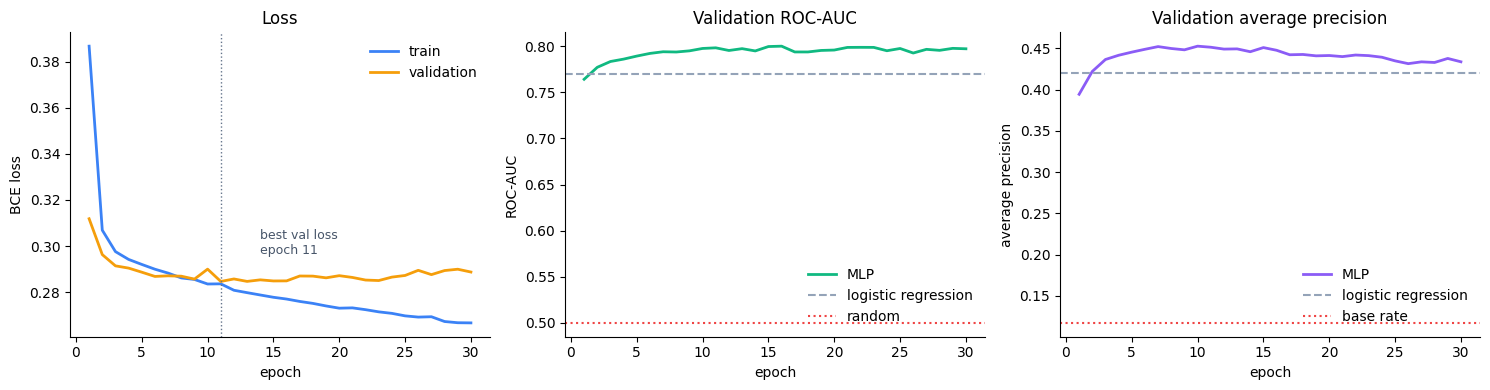

Best validation loss at epoch 11: 0.2846
Best validation ROC-AUC at epoch 16: 0.8000
Final epoch validation loss: 0.2887


In [50]:
best_loss_epoch = int(np.argmin(history["val_loss"])) + 1
best_auc_epoch = int(np.argmax(history["val_auc"])) + 1

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_axis = range(1, EPOCHS + 1)

axes[0].plot(epochs_axis, history["train_loss"], label="train", color="#3b82f6", lw=2)
axes[0].plot(epochs_axis, history["val_loss"], label="validation", color="#f59e0b", lw=2)
axes[0].axvline(best_loss_epoch, color="#64748b", ls=":", lw=1)
axes[0].annotate(f"best val loss\nepoch {best_loss_epoch}",
                 xy=(best_loss_epoch, min(history["val_loss"])),
                 xytext=(best_loss_epoch + 3, min(history["val_loss"]) + 0.012),
                 fontsize=9, color="#475569")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE loss")
axes[0].set_title("Loss"); axes[0].legend(frameon=False)

axes[1].plot(epochs_axis, history["val_auc"], color="#10b981", lw=2, label="MLP")
axes[1].axhline(logreg_auc, color="#94a3b8", ls="--", lw=1.5, label="logistic regression")
axes[1].axhline(0.5, color="#ef4444", ls=":", lw=1.5, label="random")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("Validation ROC-AUC"); axes[1].legend(frameon=False, loc="lower right")

axes[2].plot(epochs_axis, history["val_ap"], color="#8b5cf6", lw=2, label="MLP")
axes[2].axhline(logreg_ap, color="#94a3b8", ls="--", lw=1.5, label="logistic regression")
axes[2].axhline(y_val.mean(), color="#ef4444", ls=":", lw=1.5, label="base rate")
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("average precision")
axes[2].set_title("Validation average precision"); axes[2].legend(frameon=False, loc="lower right")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Best validation loss at epoch {best_loss_epoch}: {min(history['val_loss']):.4f}")
print(f"Best validation ROC-AUC at epoch {best_auc_epoch}: {max(history['val_auc']):.4f}")
print(f"Final epoch validation loss: {history['val_loss'][-1]:.4f}")

### Reading those curves

The left panel is the pattern to learn. Training loss falls steadily for all thirty epochs. Validation loss falls at first, reaches a minimum, and then **turns upward** while training loss continues to fall.

A useful mental model is:

```text
training loss ↓ + validation loss ↓   → the model is improving on both seen and unseen data
training loss ↓ + validation loss ↑   → the model is improving on the training set but becoming worse on held-out data
```

That second pattern is evidence of **overfitting**. Overfitting means the model is becoming increasingly specialised to the training examples instead of improving its ability to generalise to new examples. It does not mean the model has literally memorised every row; it means the balance has shifted toward fitting training-specific detail that does not transfer as well.

It is mild here: the validation gap is not enormous and validation ROC-AUC stays roughly flat. But the direction is clear, and the thirty-epoch run was deliberately chosen so you could see the diagnosis.

**We are not going to fix it yet.** Dropout, weight decay, learning-rate schedules, and early stopping are Day 3 material. Today’s skill is recognising the pattern before applying a remedy.

Also notice that validation **loss** can degrade earlier or more clearly than validation ROC-AUC. Loss cares about the quality and confidence of the predicted probabilities. ROC-AUC only cares about the ordering of positive and negative examples. A model can therefore become increasingly overconfident while keeping a similar ranking. That distinction becomes important later when we discuss calibration.


In [51]:
final = evaluate(model, val_loader, loss_fn, DEVICE)

print("VALIDATION RESULTS, after 30 epochs\n")
print(f"{'model':<26}{'ROC-AUC':>10}{'avg prec':>11}{'train time':>13}")
print("-" * 60)
print(f"{'majority class':<26}{0.5:>10.4f}{y_val.mean():>11.4f}{'0.00s':>13}")
print(f"{'logistic regression':<26}{logreg_auc:>10.4f}{logreg_ap:>11.4f}{logreg_time:>12.2f}s")
print(f"{'MLP (50-64-32-1)':<26}{final['roc_auc']:>10.4f}"
      f"{final['avg_precision']:>11.4f}{train_time:>12.2f}s")
print()
print(f"MLP over logistic regression: "
      f"{final['roc_auc'] - logreg_auc:+.4f} ROC-AUC, "
      f"{final['avg_precision'] - logreg_ap:+.4f} average precision")
print(f"Cost: {train_time / max(logreg_time, 1e-9):.0f}x the training time and "
      f"{count_params(model):,} parameters instead of {N_FEATURES + 1}.")

VALIDATION RESULTS, after 30 epochs

model                        ROC-AUC   avg prec   train time
------------------------------------------------------------
majority class                0.5000     0.1171        0.00s
logistic regression           0.7699     0.4201        0.03s
MLP (50-64-32-1)              0.7971     0.4338        6.24s

MLP over logistic regression: +0.0272 ROC-AUC, +0.0137 average precision
Cost: 224x the training time and 5,377 parameters instead of 51.


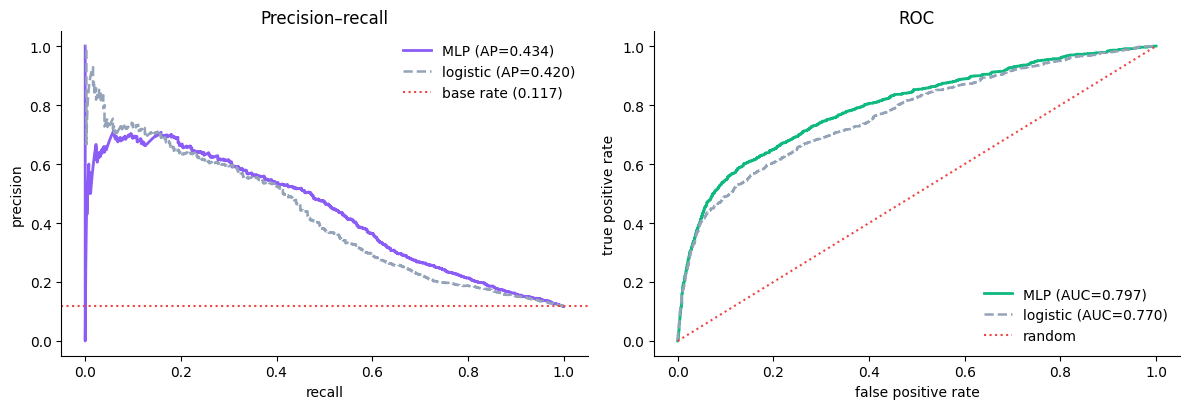

In [52]:
# What the model is worth in operational terms: precision-recall, not accuracy.
prec, rec, thresholds = precision_recall_curve(final["labels"], final["probs"])
lr_prec, lr_rec, _ = precision_recall_curve(y_val, logreg_probs)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(rec, prec, color="#8b5cf6", lw=2, label=f"MLP (AP={final['avg_precision']:.3f})")
axes[0].plot(lr_rec, lr_prec, color="#94a3b8", lw=1.8, ls="--",
             label=f"logistic (AP={logreg_ap:.3f})")
axes[0].axhline(y_val.mean(), color="#ef4444", ls=":", lw=1.5,
                label=f"base rate ({y_val.mean():.3f})")
axes[0].set_xlabel("recall"); axes[0].set_ylabel("precision")
axes[0].set_title("Precision–recall"); axes[0].legend(frameon=False)

fpr, tpr, _ = roc_curve(final["labels"], final["probs"])
lr_fpr, lr_tpr, _ = roc_curve(y_val, logreg_probs)
axes[1].plot(fpr, tpr, color="#10b981", lw=2, label=f"MLP (AUC={final['roc_auc']:.3f})")
axes[1].plot(lr_fpr, lr_tpr, color="#94a3b8", lw=1.8, ls="--",
             label=f"logistic (AUC={logreg_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="#ef4444", ls=":", lw=1.5, label="random")
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate")
axes[1].set_title("ROC"); axes[1].legend(frameon=False, loc="lower right")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [53]:
# Translate the curve into a business decision: who do we call?
budget_fraction = 0.20                        # we can afford to call 20% of the list
k = int(len(final["probs"]) * budget_fraction)
top_k = np.argsort(final["probs"])[::-1][:k]

hits = final["labels"][top_k].sum()
total_positives = final["labels"].sum()

print(f"Suppose the call centre can contact {budget_fraction:.0%} of the list "
      f"({k:,} of {len(final['probs']):,} clients).\n")
print(f"  Calling at random    : ~{int(k * y_val.mean()):,} subscribers reached "
      f"({y_val.mean():.1%} hit rate)")
print(f"  Calling the model's")
print(f"  highest-scoring {k:,}  : {int(hits):,} subscribers reached "
      f"({hits / k:.1%} hit rate)")
print(f"\n  Lift: {(hits / k) / y_val.mean():.2f}x")
print(f"  Recall at 20% of budget: {hits / total_positives:.1%} of all "
      f"{int(total_positives):,} subscribers")

Suppose the call centre can contact 20% of the list (1,356 of 6,782 clients).

  Calling at random    : ~158 subscribers reached (11.7% hit rate)
  Calling the model's
  highest-scoring 1,356  : 481 subscribers reached (35.5% hit rate)

  Lift: 3.03x
  Recall at 20% of budget: 60.6% of all 794 subscribers


### The verdict

The network beats logistic regression on the validation metrics shown above, but the margin is small relative to the additional model complexity and training cost. That is the fact to report; whether that trade-off is worthwhile is a deployment decision rather than a universal ML rule.

The operational question helps make the comparison concrete. Suppose a call centre can contact only a fixed fraction of the customer list. Then the practical task is often not:

> “Can the model label every customer correctly at a chosen threshold?”

but:

> “Can the model **rank** customers so that the limited call budget reaches more of the customers we care about?”

That distinction matters because **ranking** and **classification** are different tasks:

- **classification:** choose a threshold and turn each probability into a yes/no decision;
- **ranking:** sort customers from highest predicted risk to lowest and take the top `k` because the team can only act on `k` customers.

For the latter task, average precision, ROC-AUC, and recall at a fixed capacity can be more informative than accuracy at an arbitrary threshold.

There is also a legitimate engineering trade-off around the logistic-regression baseline. Logistic regression is fast to train, its coefficients are comparatively easy to inspect, and it has fewer moving parts. An MLP adds nonlinear capacity, which may provide a measurable lift but also adds architecture, optimisation, checkpointing, and overfitting considerations.

The note therefore does **not** claim that the MLP should automatically be deployed. It shows what the experiment measured and gives you the evidence needed to discuss the trade-off.

The broader lesson is about tabular data. Here, the raw information has already been turned into a table of engineered numerical features. A **representation** is the numerical form in which information is presented to a model. On this dataset, much of the work of representing the customer has already been done by the preprocessing pipeline. Neural networks have a stronger automatic advantage on problems where the useful representation itself must be learned from less structured raw input, such as images, audio, or text.

**Day 4 makes this comparison more rigorous**, with gradient boosting as a third contender under a controlled experimental protocol. Today’s experiment is the mechanics-and-reasoning version that motivates that comparison.


**Questions to sit with:**

1. At its best epoch the MLP reached an average precision well above what it shows in the
   final-epoch table, while its ROC-AUC barely moved between those two points. Given what each
   metric measures, what does that pattern say about which part of the ranking overfitting damaged
   first?
2. The lift calculation used the top 20% by predicted probability. Nothing in it required a
   threshold or a `predict()` call. Why is ranking, rather than classification, the more useful
   framing for this problem?
3. Argue the case for shipping logistic regression instead. What would have to be true about the
   business for that to be the better engineering decision?

## 8. Checkpointing that survives a crash

A **checkpoint** is a saved snapshot of training state. Saving only the model’s weights is enough to use the model for inference, but it is not enough to guarantee that you can continue training as if the interruption had never happened.

A resumable checkpoint here stores four essential pieces:

- **model state:** the learned weights and biases;
- **optimizer state:** information Adam has accumulated about the recent gradients and its update process;
- **epoch:** where training had reached;
- **config:** the settings needed to reconstruct the architecture and training setup, such as `hidden_sizes`, input width, learning rate, and batch size.

Think of the distinction this way:

```text
model weights     = what the network has learned
optimizer state   = what the optimizer remembers about how it has been learning
training position = where the run stopped
config            = how the model was constructed and trained
```

Save the `state_dict`, not the whole model object. Pickling the whole object ties the file to the Python class and module path used to create it; a refactor can therefore make an old pickled object difficult or impossible to load. A state dictionary stores the model state separately from the Python object definition, so the code can reconstruct the architecture explicitly.

In [54]:
CONFIG = {
    "in_features": N_FEATURES,
    "hidden_sizes": (64, 32),
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "seed": SEED,
}


def save_checkpoint(path, model, optimizer, epoch, history, config, extra=None):
    torch.save({
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "epoch": epoch,
        "history": history,
        "config": config,
        "torch_version": torch.__version__,
        **(extra or {}),
    }, path)
    return Path(path).stat().st_size


ckpt_path = CKPT_DIR / "bank_mlp.pt"
size = save_checkpoint(ckpt_path, model, optimizer, EPOCHS, history, CONFIG,
                       extra={"val_roc_auc": final["roc_auc"]})

print(f"Saved {ckpt_path} ({size / 1024:.1f} KB)")
print(f"\nWeights alone would be {count_params(model) * 4 / 1024:.1f} KB.")
print("The file is larger because Adam's two moment buffers are one float per")
print("parameter each — optimizer state roughly triples a checkpoint.")

print("\nstate_dict keys (these are the module-tree paths from Section 2):")
for k, v in list(model.state_dict().items()):
    print(f"  {k:<26} {tuple(v.shape)}")

Saved checkpoints/bank_mlp.pt (72.2 KB)

Weights alone would be 21.0 KB.
The file is larger because Adam's two moment buffers are one float per
parameter each — optimizer state roughly triples a checkpoint.

state_dict keys (these are the module-tree paths from Section 2):
  blocks.0.linear.weight     (64, 50)
  blocks.0.linear.bias       (64,)
  blocks.1.linear.weight     (32, 64)
  blocks.1.linear.bias       (32,)
  head.weight                (1, 32)
  head.bias                  (1,)


In [55]:
def load_checkpoint(path, device):
    """Rebuild model and optimizer from a checkpoint. Returns (model, optimizer, ckpt)."""
    ckpt = torch.load(path, map_location=device, weights_only=False)
    cfg = ckpt["config"]

    restored_model = BankMLP(cfg["in_features"], hidden_sizes=cfg["hidden_sizes"]).to(device)
    restored_model.load_state_dict(ckpt["model_state_dict"])

    restored_opt = torch.optim.Adam(restored_model.parameters(), lr=cfg["learning_rate"])
    restored_opt.load_state_dict(ckpt["optimizer_state_dict"])

    return restored_model, restored_opt, ckpt


restored, restored_opt, ckpt = load_checkpoint(ckpt_path, DEVICE)

print(f"Restored from epoch {ckpt['epoch']}, "
      f"saved with torch {ckpt['torch_version']}")
print(f"Recorded validation ROC-AUC: {ckpt['val_roc_auc']:.4f}")

check = evaluate(restored, val_loader, loss_fn, DEVICE)
print(f"\nRe-evaluated ROC-AUC       : {check['roc_auc']:.4f}")
print(f"Difference                 : {abs(check['roc_auc'] - final['roc_auc']):.2e}")
assert np.allclose(check["probs"], final["probs"], atol=1e-6), "restored model must match"
print("Restored model reproduces the original predictions exactly.")

Restored from epoch 30, saved with torch 2.14.0
Recorded validation ROC-AUC: 0.7971



Re-evaluated ROC-AUC       : 0.7971
Difference                 : 0.00e+00
Restored model reproduces the original predictions exactly.


In [56]:
# Does the optimizer state actually matter? Measure rather than assume.
def resume_and_train(model_src, opt_state, n_epochs=3):
    m = BankMLP(N_FEATURES, hidden_sizes=(64, 32)).to(DEVICE)
    m.load_state_dict(model_src.state_dict())
    o = torch.optim.Adam(m.parameters(), lr=LEARNING_RATE)
    if opt_state is not None:
        o.load_state_dict(opt_state)
    losses = []
    for _ in range(n_epochs):
        losses.append(train_one_epoch(m, train_loader, loss_fn, o, DEVICE))
    return losses


seed_everything(SEED)
with_state = resume_and_train(restored, ckpt["optimizer_state_dict"])
seed_everything(SEED)
without_state = resume_and_train(restored, None)

print("Resuming for 3 epochs from the same weights:\n")
print(f"{'epoch':>7}{'with optimizer state':>24}{'fresh optimizer':>19}{'difference':>14}")
for i, (a, b) in enumerate(zip(with_state, without_state), start=1):
    print(f"{i:>7}{a:>24.5f}{b:>19.5f}{abs(a - b):>14.5f}")
print()
print("Barely any difference. That is the honest result on THIS problem, and it")
print("is worth understanding rather than explaining away -- see the note below.")

Resuming for 3 epochs from the same weights:

  epoch    with optimizer state    fresh optimizer    difference
      1                 0.26536            0.26541       0.00006
      2                 0.26425            0.26380       0.00045
      3                 0.26366            0.26323       0.00043

Barely any difference. That is the honest result on THIS problem, and it
is worth understanding rather than explaining away -- see the note below.


### What that measurement actually showed

The two resumed runs are almost indistinguishable **on this particular problem and for this short continuation**. A fresh Adam loses its accumulated running statistics and starts those estimates again, but this small model sees 124 batches per epoch, so the new optimizer quickly rebuilds useful estimates.

That observation should **not** be turned into the rule “optimizer state does not matter.” The experiment only tells us what happened under these conditions. The optimizer state matters more when rebuilding it consumes a substantial fraction of the remaining training process, for example:

- resuming in the middle of an epoch or with only a few hundred optimisation steps left;
- fine-tuning, where the entire run may be short;
- using a learning-rate scheduler whose internal step position must also be restored;
- working with a large model where wasted steps are expensive.

The engineering conclusion is therefore about **risk and reproducibility**: save the optimizer state when you intend to resume training. The experiment is useful because it tells you that forgetting it may produce no obvious symptom on one small experiment — which is exactly why the bug can survive unnoticed.

`weights_only=False` above is required because this checkpoint contains ordinary Python dictionaries such as the config and history, not only tensors. Loading with that setting can unpickle Python objects, so only load checkpoints you produced yourself or otherwise trust. For a checkpoint that will be distributed, keep the serialised tensor state separate from trusted configuration data, as Note 2.4 does.

**Questions to sit with:**

1. The checkpoint stores `hidden_sizes` in its config. What breaks if you omit that information and later change `BankMLP`’s default from `(64, 32)` to `(128, 64)`?
2. Adam keeps roughly two additional floating-point values per parameter for its moment estimates. For a 7-billion-parameter model, how large is that optimizer state in `float32`, and what does that imply for fine-tuning on a single GPU?


## 9. Now modify the loop yourself

Day 2’s end-of-day competency is *building a neural network and writing or modifying its training loop*. Running someone else’s loop is not the same skill.

The three modifications below are deliberately small. Each one changes one part of the experiment while leaving the rest of the training mechanism recognisable.

### Modification 1: weight the positive class

`BCEWithLogitsLoss(pos_weight=w)` changes the training objective by multiplying the loss contribution from positive examples by `w`. With an 11.7% positive rate, the natural demonstration value is the ratio of negative examples to positive examples.

The important conceptual distinction is that **changing the training objective is not the same thing as changing the decision threshold later**. We will measure both the ranking and the threshold-based behaviour so you can see the difference rather than relying on a slogan.

In [57]:
pos_weight_value = (1 - y_train.mean()) / y_train.mean()
print(f"negatives per positive: {pos_weight_value:.2f}")


def run_experiment(pos_weight=None, epochs=15, label=""):
    seed_everything(SEED)
    m = BankMLP(N_FEATURES, hidden_sizes=(64, 32)).to(DEVICE)
    o = torch.optim.Adam(m.parameters(), lr=LEARNING_RATE)
    lf = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([pos_weight], dtype=torch.float32, device=DEVICE) if pos_weight else None)
    eval_fn = nn.BCEWithLogitsLoss()      # evaluate on the UNWEIGHTED loss, always

    for _ in range(epochs):
        train_one_epoch(m, train_loader, lf, o, DEVICE)
    return m, evaluate(m, val_loader, eval_fn, DEVICE)


m_plain, r_plain = run_experiment(None, 15, "unweighted")
m_weighted, r_weighted = run_experiment(pos_weight_value, 15, "weighted")

print(f"\n{'run':<22}{'ROC-AUC':>10}{'avg prec':>11}{'mean P(yes)':>14}")
print("-" * 57)
print(f"{'unweighted':<22}{r_plain['roc_auc']:>10.4f}"
      f"{r_plain['avg_precision']:>11.4f}{r_plain['probs'].mean():>14.4f}")
print(f"{'pos_weight=' + f'{pos_weight_value:.1f}':<22}{r_weighted['roc_auc']:>10.4f}"
      f"{r_weighted['avg_precision']:>11.4f}{r_weighted['probs'].mean():>14.4f}")
print(f"\nActual positive rate: {y_val.mean():.4f}")

negatives per positive: 7.55



run                      ROC-AUC   avg prec   mean P(yes)
---------------------------------------------------------
unweighted                0.7968     0.4464        0.1080
pos_weight=7.5            0.7989     0.4478        0.3620

Actual positive rate: 0.1171


run                     precision    recall      F1  (threshold 0.5)
-----------------------------------------------------
unweighted                 0.6553    0.2418  0.3533
weighted                   0.3318    0.6398  0.4370


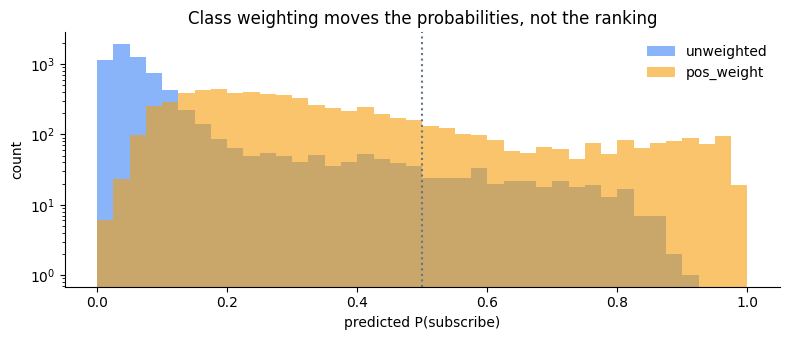

In [58]:
# Where the weighting actually changes behaviour: the default 0.5 threshold.
print(f"{'run':<22}{'precision':>11}{'recall':>10}{'F1':>8}  (threshold 0.5)")
print("-" * 53)
for name, res in [("unweighted", r_plain), ("weighted", r_weighted)]:
    pred = (res["probs"] >= 0.5).astype(int)
    tn, fp, fn_, tp = confusion_matrix(res["labels"], pred).ravel()
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn_, 1)
    f1 = f1_score(res["labels"], pred)
    print(f"{name:<22}{precision:>11.4f}{recall:>10.4f}{f1:>8.4f}")

fig, ax = plt.subplots(figsize=(8, 3.5))
bins = np.linspace(0, 1, 41)
ax.hist(r_plain["probs"], bins=bins, alpha=0.6, label="unweighted", color="#3b82f6")
ax.hist(r_weighted["probs"], bins=bins, alpha=0.6, label="pos_weight", color="#f59e0b")
ax.axvline(0.5, color="#64748b", ls=":", lw=1.5)
ax.set_xlabel("predicted P(subscribe)"); ax.set_ylabel("count")
ax.set_yscale("log")
ax.set_title("Class weighting moves the probabilities, not the ranking")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

This is the result worth understanding, because it separates two effects that are often mixed together.

Class weighting changed the **training objective**: positive examples counted more heavily when the model learned. In this experiment it barely moved ROC-AUC or average precision, which are primarily measures of **ranking**. What changed substantially was the distribution of predicted probabilities and therefore the behaviour of the default `0.5` threshold: recall increased while precision decreased.

An **operating point** is simply the particular decision rule you choose after the model has produced scores. For example:

```text
probability >= 0.50  → act
probability <  0.50  → do not act
```

Changing that threshold moves you to a different precision/recall trade-off without retraining the model.

The weighted model in this experiment is also less **calibrated**. Calibration asks whether predicted probabilities correspond to observed frequencies. For example, among cases assigned approximately 0.70 probability, a well-calibrated model would have an observed positive rate near 70% over a large enough group. A model can preserve its ranking while its probability scale becomes poorly calibrated.

So the practical distinction is:

- **loss weighting:** change what the model is encouraged to care about while learning;
- **threshold selection:** change which scores are converted into actions after the model is trained.

They can sometimes lead to similar precision/recall trade-offs, but they are not the same intervention and they have different effects on the learned scores and calibration.

Choose deliberately based on the objective you are trying to optimise.

### Modification 2: add a metric to the loop

Adding a per-epoch metric is a small code change, but it teaches an important general pattern: a training loop can record quantities that describe both optimisation behaviour and the business-facing outcome you actually care about.


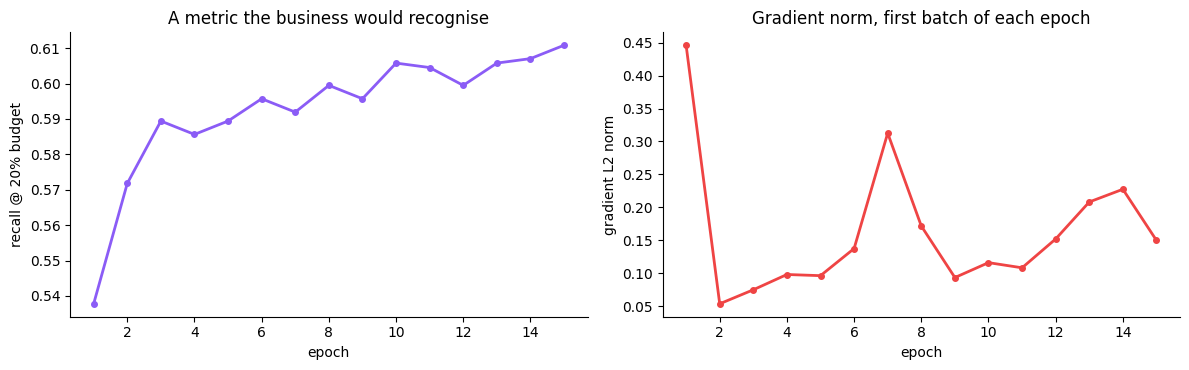

recall@20%: 0.538 (epoch 1) -> 0.611 (epoch 15)
grad norm : 0.4461 (epoch 1) -> 0.1499 (epoch 15)

Gradient norm shrinking as training proceeds is what convergence looks like.
A norm that grows without bound is an exploding gradient. Day 3 covers both.


In [59]:
def train_with_extra_metric(model, epochs=15):
    """Same loop, plus recall-at-20%-budget tracked every epoch."""
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    lf = nn.BCEWithLogitsLoss()
    log = {"val_ap": [], "recall_at_20pct": [], "grad_norm": []}

    for _ in range(epochs):
        # --- the extra: capture gradient norm on the first batch of each epoch ---
        model.train()
        first = True
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = lf(model(xb), yb)
            loss.backward()
            if first:
                total_norm = torch.sqrt(sum((p.grad ** 2).sum() for p in model.parameters()))
                log["grad_norm"].append(total_norm.item())
                first = False
            optimizer.step()

        res = evaluate(model, val_loader, lf, DEVICE)
        k = int(len(res["probs"]) * 0.20)
        top = np.argsort(res["probs"])[::-1][:k]
        log["val_ap"].append(res["avg_precision"])
        log["recall_at_20pct"].append(res["labels"][top].sum() / res["labels"].sum())

    return log


seed_everything(SEED)
m_metric = BankMLP(N_FEATURES, hidden_sizes=(64, 32)).to(DEVICE)
log = train_with_extra_metric(m_metric, epochs=15)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(range(1, 16), log["recall_at_20pct"], color="#8b5cf6", lw=2, marker="o", ms=4)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("recall @ 20% budget")
axes[0].set_title("A metric the business would recognise")

axes[1].plot(range(1, 16), log["grad_norm"], color="#ef4444", lw=2, marker="o", ms=4)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("gradient L2 norm")
axes[1].set_title("Gradient norm, first batch of each epoch")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"recall@20%: {log['recall_at_20pct'][0]:.3f} (epoch 1) "
      f"-> {log['recall_at_20pct'][-1]:.3f} (epoch 15)")
print(f"grad norm : {log['grad_norm'][0]:.4f} (epoch 1) "
      f"-> {log['grad_norm'][-1]:.4f} (epoch 15)")
print("\nGradient norm shrinking as training proceeds is what convergence looks like.")
print("A norm that grows without bound is an exploding gradient. Day 3 covers both.")

### Modification 3: early stopping, written by hand

Section 7 showed validation loss bottoming out in the low teens and drifting upward for the
remaining two-thirds of the run. Early stopping keeps the best model and stops paying for epochs that make things worse.

Writing it yourself once — rather than importing a callback — makes the mechanism concrete: track
the best score, count epochs since it improved, keep a copy of the winning weights.

In [60]:
def train_with_early_stopping(max_epochs=60, patience=5, min_delta=1e-4):
    seed_everything(SEED)
    m = BankMLP(N_FEATURES, hidden_sizes=(64, 32)).to(DEVICE)
    o = torch.optim.Adam(m.parameters(), lr=LEARNING_RATE)
    lf = nn.BCEWithLogitsLoss()

    best_loss = float("inf")
    best_epoch = 0
    best_weights = None
    epochs_without_improvement = 0
    curve = []

    for epoch in range(1, max_epochs + 1):
        train_one_epoch(m, train_loader, lf, o, DEVICE)
        res = evaluate(m, val_loader, lf, DEVICE)
        curve.append(res["loss"])

        if res["loss"] < best_loss - min_delta:
            best_loss = res["loss"]
            best_epoch = epoch
            best_weights = copy.deepcopy(m.state_dict())     # deepcopy: state_dict shares storage
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Stopped at epoch {epoch}: no improvement for {patience} epochs.")
                break
    else:
        print(f"Ran the full {max_epochs} epochs without triggering.")

    m.load_state_dict(best_weights)      # restore the best, not the last
    return m, best_epoch, best_loss, curve


best_model, best_epoch, best_loss, curve = train_with_early_stopping()

print(f"Best epoch {best_epoch}, validation loss {best_loss:.4f}")
print(f"Epochs actually run: {len(curve)} (of a 60 budget)")

es_result = evaluate(best_model, val_loader, nn.BCEWithLogitsLoss(), DEVICE)
print(f"\n{'model':<32}{'val loss':>10}{'ROC-AUC':>10}{'avg prec':>11}")
print("-" * 63)
print(f"{'30 epochs, last weights':<32}{history['val_loss'][-1]:>10.4f}"
      f"{final['roc_auc']:>10.4f}{final['avg_precision']:>11.4f}")
print(f"{f'early stopped, best (ep {best_epoch})':<32}{best_loss:>10.4f}"
      f"{es_result['roc_auc']:>10.4f}{es_result['avg_precision']:>11.4f}")

Stopped at epoch 16: no improvement for 5 epochs.
Best epoch 11, validation loss 0.2846
Epochs actually run: 16 (of a 60 budget)

model                             val loss   ROC-AUC   avg prec
---------------------------------------------------------------
30 epochs, last weights             0.2887    0.7971     0.4338
early stopped, best (ep 11)         0.2846    0.7982     0.4515


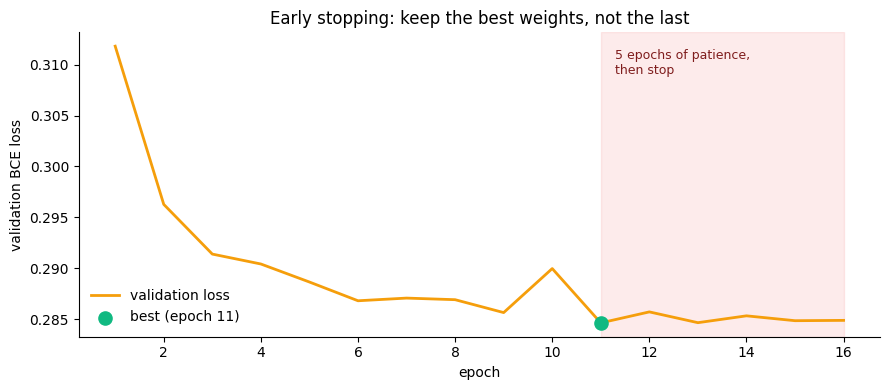

In [61]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(curve) + 1), curve, color="#f59e0b", lw=2, label="validation loss")
ax.scatter([best_epoch], [best_loss], color="#10b981", s=90, zorder=5,
           label=f"best (epoch {best_epoch})")
ax.axvspan(best_epoch, len(curve), alpha=0.10, color="#ef4444")
ax.text(best_epoch + 0.3, max(curve) * 0.999,
        f"{len(curve) - best_epoch} epochs of patience,\nthen stop",
        fontsize=9, color="#7f1d1d", va="top")
ax.set_xlabel("epoch"); ax.set_ylabel("validation BCE loss")
ax.set_title("Early stopping: keep the best weights, not the last")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Two details in that implementation are load-bearing.

`copy.deepcopy(m.state_dict())` is necessary because the tensors returned by `state_dict()` refer to the model’s current underlying storage. If you merely keep the dictionary and continue training, the live model keeps changing the values those references point to. Your supposed “best weights” can therefore silently become the latest weights.

`deepcopy` creates independent copies of the state tensors. Now the snapshot really is a snapshot, so `load_state_dict(best_weights)` can restore the model to the parameter values that produced the best validation loss.

`min_delta` defines what counts as a meaningful improvement. Without it, tiny floating-point changes can repeatedly reset the patience counter even when the validation loss is effectively unchanged.

**Patience** is the number of consecutive epochs you are willing to wait without meaningful improvement before stopping. Early stopping therefore has two jobs: identify the best validation point seen so far, and stop spending computation after the model has failed to improve for long enough.

**Note the honest caveat.** Early stopping chooses an epoch by looking at the validation set. That means the selected validation score is mildly optimistic because you chose the best result among many measurements on the same set. This is why a separate test set exists and why we have not used ours to choose the stopping point. Day 4 treats this issue more formally.


### Your turn

Three exercises, in increasing difficulty. Each is a modification to code above, not a rewrite.

1. **Track precision at a fixed recall.** Add a metric to `train_with_extra_metric` that reports precision at the threshold where recall first reaches 0.50. Which epoch is best by that measure, and is it the same epoch that minimises validation loss? Explain why the two criteria can disagree.
2. **Make the width configurable and sweep it.** `BankMLP` already accepts `hidden_sizes`. Train `(16,)`, `(64, 32)` and `(256, 128, 64)` for fifteen epochs each, and plot validation average precision against parameter count. Does more capacity help on this dataset? Predict first, then measure.
3. **Early stopping on the right quantity.** The implementation above monitors validation *loss*. Rewrite it to monitor average precision instead — note that the comparison direction flips because higher average precision is better. Do the two criteria choose the same epoch? If not, explain the difference in terms of what each quantity measures and the business objective you established earlier.


<a id="s10"></a>
## 10. Conclusion

You built an MLP, trained it with a loop you wrote, and evaluated it against baselines that make the result contestable rather than automatic. The main lesson is not a collection of API calls. It is understanding what each piece of the training system is responsible for.

**On `nn.Module`.** A PyTorch module is both the place where you define the forward computation and the structure PyTorch uses to register child modules and parameters. Registration is what lets optimizers find trainable tensors, device movement reach the model’s state, checkpoints collect that state, and mode changes propagate through the module tree. A layer hidden inside a plain Python list is not automatically registered.

**On shapes.** A shape is the size of a tensor along each dimension. Dry-run a fake batch before real data touches the model. Forward hooks let you inspect intermediate inputs and outputs when one shape check is not enough. Both techniques are cheap debugging tools because they test the model’s wiring independently of the dataset.

**On the output head.** For binary classification you can use one raw logit with `BCEWithLogitsLoss` or two class logits with `CrossEntropyLoss`. Both are valid. The important rule is to match the output representation, label format, and loss function. When the loss expects logits, do not add a sigmoid or softmax to `forward` just to obtain probabilities during training.

**On the loop.** The core sequence is:

```text
clear old gradients
        ↓
forward pass
        ↓
calculate loss
        ↓
backward pass → gradients
        ↓
optimizer step → updated parameters
```

The surrounding bookkeeping matters just as much: accumulate `loss.item()`, weight batch means by actual batch size when calculating a dataset-level mean, and make the training/evaluation mode explicit.

**On `eval()` and `no_grad()`.** They solve different problems. `eval()` changes the behaviour of modules that have training/evaluation modes. `no_grad()` prevents PyTorch from building a gradient graph when gradients are not needed. A correct validation pass normally uses both.

**On the result.** The MLP produced a measurable validation improvement over logistic regression in this experiment, but the margin was small compared with the additional machinery. Whether that trade-off is worthwhile depends on the deployment requirements. The experiment therefore informs an engineering decision; it does not make that decision for you.

**On ranking.** A probability model can be used in two different ways: choose a threshold and classify everyone, or sort everyone by score and act on the highest-ranked cases. When operational capacity is limited, ranking can be the more direct representation of the problem. That is why ROC-AUC, average precision, and recall at a fixed budget appear alongside threshold-based metrics.

**On the curves.** Validation loss eventually turned upward while training loss continued downward. That is the observable pattern of overfitting: optimisation on the training set continues while held-out performance stops improving. We deliberately diagnosed it before applying a remedy.

**On modification.** You changed the class weighting, observed how it affected the score distribution and threshold behaviour, added metrics and a gradient-norm probe, and implemented early stopping yourself. You also saw why a best-weight snapshot must be a real copy and why a resumable checkpoint needs more than the model weights.

If you can explain these mechanisms rather than merely reproduce the code, you are no longer just running a training loop — you understand enough of it to modify and defend it.


### Transition to Note 2.4

Everything above lives in a notebook. Notebooks are excellent for the exploratory work you have just done — inspecting tensors, plotting curves, changing one thing, and rerunning cells. They become less suitable when you need a repeatable software artifact.

The problem is **execution state**: notebook cells can be run out of order, the exact settings used for an experiment can be hidden in earlier cells, and another program cannot cleanly import a single part of the notebook. Reproducing an experiment therefore becomes harder as the project grows.

Note 2.4 fixes this by moving the same ideas into a normal project structure. Its cells write real files — `src/data/`, `src/models/`, `src/training/`, `configs/`, a `README.md`, and a `.gitignore` — and its final section runs the training from the command line:

```text
python -m src.training.train --config configs/baseline.yaml
```

The goal is not to abandon notebooks. It is to move the code that should be reusable, testable, reviewable, and repeatable into a project structure while keeping notebooks available for exploration.

Note 2.4 also covers environment and dependency pinning so the software versions are explicit, and Git practices so changes can be reviewed. The project skeleton is the same structure Day 10 requires for the final portfolio artifact.
